# 01. Data overview

Minimal first check: load metadata, TAX and PATH tables, align by `run`, show sample groups and matrix sizes.

In [1]:
from pathlib import Path

# Main paths. Usually only this cell needs editing.
PROJECT_DIR = Path(".").resolve()
DATA_DIR = PROJECT_DIR / "data"
OUT_DIR = PROJECT_DIR / "outputs_minimal"

TAX_PATH = DATA_DIR / "tax.csv"
PATHWAY_PATH = DATA_DIR / "path.csv"
METADATA_PATH = DATA_DIR / "metadata.csv"

FIG_DIR = OUT_DIR / "figures"
RESULTS_DIR = OUT_DIR / "results"

FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("TAX:", TAX_PATH)
print("PATH:", PATHWAY_PATH)
print("METADATA:", METADATA_PATH)
print("OUT:", OUT_DIR)

TAX: /srv/common/seraph/workshop/code/data/tax.csv
PATH: /srv/common/seraph/workshop/code/data/path.csv
METADATA: /srv/common/seraph/workshop/code/data/metadata.csv
OUT: /srv/common/seraph/workshop/code/outputs_minimal


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from simple_utils import GROUP_ORDER, load_data

In [3]:
bundle = load_data(TAX_PATH, PATHWAY_PATH, METADATA_PATH)

print("Samples:", len(bundle.meta))
print("TAX features:", bundle.tax.shape[1])
print("PATH features:", bundle.path.shape[1])
print("Bioprojects:", bundle.meta["bioproject"].nunique())

bundle.meta["group"].value_counts().reindex(GROUP_ORDER).fillna(0).astype(int)

Samples: 193
TAX features: 719
PATH features: 522
Bioprojects: 1


group
Healthy                64
Caries (K02)           42
Periodontitis (K05)    56
K02+K05                31
Name: count, dtype: int64

In [4]:
summary = (
    bundle.meta
    .groupby(["bioproject", "group"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=GROUP_ORDER, fill_value=0)
)

summary.to_csv(RESULTS_DIR / "sample_counts_by_bioproject.csv")
summary

group,Healthy,Caries (K02),Periodontitis (K05),K02+K05
bioproject,,,,
PRJNA1057503,64,42,56,31


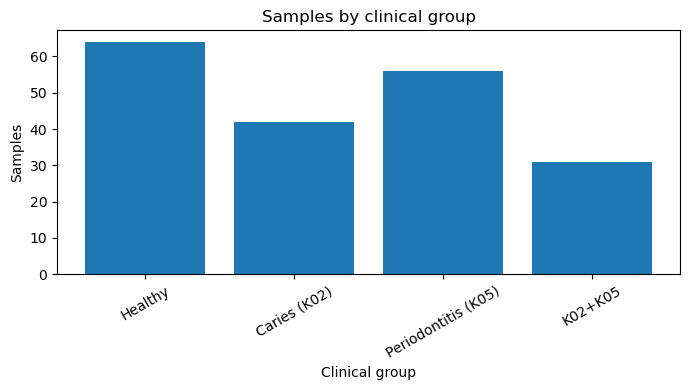

In [5]:
group_counts = bundle.meta["group"].value_counts().reindex(GROUP_ORDER).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(group_counts.index, group_counts.values)
ax.set_title("Samples by clinical group")
ax.set_xlabel("Clinical group")
ax.set_ylabel("Samples")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / "sample_counts_by_group.png", dpi=200)
plt.show()

In [6]:
basic_qc = pd.DataFrame({
    "metadata_missing_cells": [int(bundle.meta.isna().sum().sum())],
    "tax_missing_cells": [int(bundle.tax.isna().sum().sum())],
    "path_missing_cells": [int(bundle.path.isna().sum().sum())],
    "metadata_duplicate_runs": [int(bundle.meta.index.duplicated().sum())],
    "tax_duplicate_runs": [int(bundle.tax.index.duplicated().sum())],
    "path_duplicate_runs": [int(bundle.path.index.duplicated().sum())],
})

basic_qc.to_csv(RESULTS_DIR / "basic_qc.csv", index=False)
basic_qc

,metadata_missing_cells,tax_missing_cells,path_missing_cells,metadata_duplicate_runs,tax_duplicate_runs,path_duplicate_runs
0,0,0,0,0,0,0
